

========== Physical Parameters ==========
Cart Mass          : 1.000 kg
Pole Mass          : 0.100 kg
Pole COM Distance  : 0.250 m
Gravity            : 9.810 m/s²

========== LQR ==========
Q Matrix
[[5.e+01 0.e+00 0.e+00 0.e+00]
 [0.e+00 8.e+02 0.e+00 0.e+00]
 [0.e+00 0.e+00 5.e-01 0.e+00]
 [0.e+00 0.e+00 0.e+00 5.e+00]]

R Matrix
[[0.01]]

Gain Matrix K
[[ -55.7082 -294.4381  -59.7887  -36.5053]]


Peak Values

Pole Angle            : -35.0124 at 0.290 s
Cart Position         : +1.0100 at 0.415 s
Control Force         : +154.1674 at 0.005 s


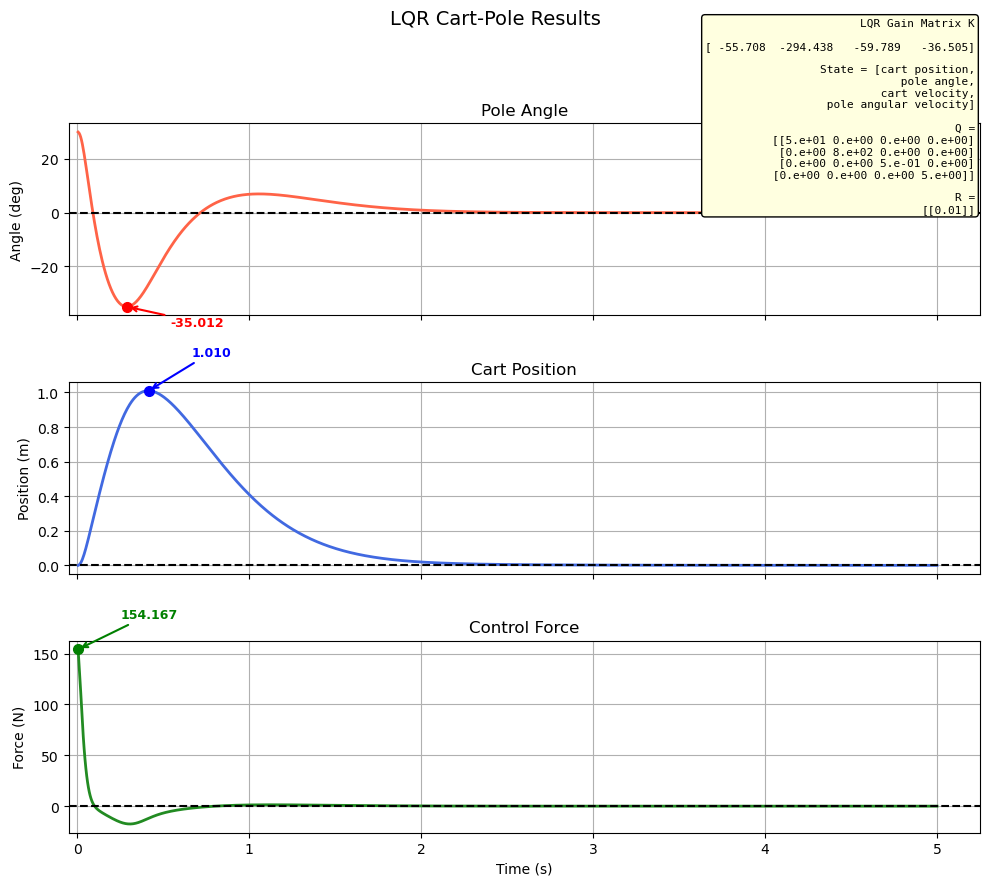

In [2]:
import time
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
import mujoco
import mujoco.viewer

# ============================================================
#                     MuJoCo MODEL
# ============================================================

CARTPOLE_XML = """
<mujoco model="cartpole">

  <option gravity="0 0 -9.81"
          timestep="0.005"/>

  <default>
    <joint damping="0.0"/>
  </default>

  <worldbody>

    <geom
        name="rail"
        type="capsule"
        pos="0 0 0"
        size="0.02 30"
        euler="0 90 0"
        rgba="0.4 0.4 0.4 1"
        contype="0"
        conaffinity="0"/>

    <body name="cart" pos="0 0 0">

      <joint
          name="slider"
          type="slide"
          axis="1 0 0"
          limited="true"
          range="-10 10"
          damping="0.5"/>

      <geom
          type="box"
          size="0.15 0.08 0.05"
          rgba="0.3 0.6 0.9 1"
          mass="1.0"/>

      <body name="pole" pos="0 0 0.05">

        <joint
            name="hinge"
            type="hinge"
            axis="0 1 0"
            damping="0.05"/>

        <geom
            type="capsule"
            fromto="0 0 0 0 0 0.5"
            size="0.015"
            rgba="0.85 0.35 0.15 1"
            mass="0.1"/>

        <geom
            type="sphere"
            pos="0 0 0.5"
            size="0.05"
            rgba="1 0.85 0.1 1"
            mass="0"/>

      </body>

    </body>

  </worldbody>

  <actuator>

    <motor
        name="cart_force"
        joint="slider"
        gear="1"
        ctrllimited="true"
        ctrlrange="-100 100"/>

  </actuator>

</mujoco>
"""

# ============================================================
#                 LQR TUNING PARAMETERS
# ============================================================

CONTROL_LIMIT = 10000.0

Q = np.diag([
    50.0,     # Cart position
    800.0,    # Pole angle
    0.5,     # Cart velocity
    5.0      # Pole angular velocity
])

R = np.array([
    [.01]   # Control effort
])
print ()
# ============================================================
#             READ PHYSICAL PARAMETERS FROM MODEL
# ============================================================

def get_physical_params(model):

    cart_body = mujoco.mj_name2id(
        model,
        mujoco.mjtObj.mjOBJ_BODY,
        "cart"
    )

    pole_body = mujoco.mj_name2id(
        model,
        mujoco.mjtObj.mjOBJ_BODY,
        "pole"
    )

    M = model.body_mass[cart_body]
    m = model.body_mass[pole_body]
    l = float(model.body_ipos[pole_body][2])
    g = abs(model.opt.gravity[2])

    print("\n========== Physical Parameters ==========")
    print(f"Cart Mass          : {M:.3f} kg")
    print(f"Pole Mass          : {m:.3f} kg")
    print(f"Pole COM Distance  : {l:.3f} m")
    print(f"Gravity            : {g:.3f} m/s²")
    print("=========================================\n")

    return M, m, l, g


# ============================================================
#             CONTINUOUS LINEARIZED MODEL
# ============================================================

def build_linearised_system(M, m, l, g):

    total = M + m

    A = np.array([
        [0, 0, 1, 0],
        [0, 0, 0, 1],
        [0, -(m * g) / total, 0, 0],
        [0, g / l, 0, 0]
    ])

    B = np.array([
        [0],
        [0],
        [1 / total],
        [-1 / (l * total)]
    ])

    return A, B


# ============================================================
#                  DISCRETIZATION
# ============================================================

def discretise(A, B, dt):

    n = A.shape[0]

    augmented = np.block([
        [A, B],
        [np.zeros((1, n + 1))]
    ])

    expm = scipy.linalg.expm(augmented * dt)

    Ad = expm[:n, :n]
    Bd = expm[:n, n:]

    return Ad, Bd


# ============================================================
#                   DISCRETE LQR
# ============================================================

def compute_lqr_gain(Ad, Bd, Q, R):

    P = scipy.linalg.solve_discrete_are(Ad, Bd, Q, R)

    K = np.linalg.inv(
        R + Bd.T @ P @ Bd
    ) @ (Bd.T @ P @ Ad)

    return K
    #print cost of the LQR controller


# ============================================================
#                CURRENT SYSTEM STATE
# ============================================================

def get_state(data):

    return np.array([
        data.qpos[0],
        data.qpos[1],
        data.qvel[0],
        data.qvel[1]
    ])


# ============================================================
#                 MAIN SIMULATION
# ============================================================

def run_simulation(render=True, duration=30.0):

    model = mujoco.MjModel.from_xml_string(CARTPOLE_XML)
    data = mujoco.MjData(model)

    dt = model.opt.timestep

    M, m, l, g = get_physical_params(model)

    A, B = build_linearised_system(M, m, l, g)

    Ad, Bd = discretise(A, B, dt)

    K = compute_lqr_gain(
        Ad,
        Bd,
        Q,
        R
    )

    print("========== LQR ==========")
    print("Q Matrix")
    print(Q)
    print()

    print("R Matrix")
    print(R)
    print()

    print("Gain Matrix K")
    print(np.round(K, 4))
    print("=========================\n")

    mujoco.mj_resetData(model, data)

    data.qpos[1] = np.deg2rad(30)

    mujoco.mj_forward(model, data)

    steps = int(duration / dt)

    times = []
    states = []
    controls = []

    if render:

        with mujoco.viewer.launch_passive(model, data) as viewer:

            start = time.time()

            for _ in range(steps):

                if not viewer.is_running():
                    break

                state = get_state(data)

                control = float((-K @ state)[0])

                control = np.clip(
                    control,
                    -CONTROL_LIMIT,
                    CONTROL_LIMIT
                )

                data.ctrl[0] = control

                mujoco.mj_step(model, data)

                times.append(data.time)
                states.append(state.copy())
                controls.append(control)

                elapsed = time.time() - start

                if data.time > elapsed:
                    time.sleep(data.time - elapsed)

                viewer.sync()

    else:

        for _ in range(steps):

            state = get_state(data)

            control = float((-K @ state)[0])

            control = np.clip(
                control,
                -CONTROL_LIMIT,
                CONTROL_LIMIT
            )

            data.ctrl[0] = control

            mujoco.mj_step(model, data)

            times.append(data.time)
            states.append(state.copy())
            controls.append(control)

    return (
        np.array(times),
        np.array(states),
        np.array(controls),
        K
    )


# ============================================================
#                  PASTE PART 2 BELOW
# ============================================================

# ============================================================
#                    PLOTTING
# ============================================================

def annotate_peak(ax, times, values, color, label):

    idx = np.argmax(np.abs(values))

    peak_time = times[idx]
    peak_value = values[idx]

    print(f"{label:<22}: {peak_value:+.4f} at {peak_time:.3f} s")

    ax.plot(
        peak_time,
        peak_value,
        "o",
        color=color,
        markersize=7
    )

    x_offset = (times[-1] - times[0]) * 0.05

    if peak_value >= 0:
        y_text = peak_value * 1.2
    else:
        y_text = peak_value * 1.2

    ax.annotate(
        f"{peak_value:.3f}",
        xy=(peak_time, peak_value),
        xytext=(peak_time + x_offset, y_text),
        arrowprops=dict(
            arrowstyle="->",
            color=color,
            lw=1.5
        ),
        color=color,
        fontsize=9,
        fontweight="bold"
    )
    

# ============================================================
#                  RESULT PLOTS
# ============================================================

def plot_results(times, states, controls, K):

    pole_angle = np.rad2deg(states[:, 1])
    cart_position = states[:, 0]

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(10, 9),
        sharex=True
    )

    fig.suptitle(
        "LQR Cart-Pole Results",
        fontsize=14
    )

    k = K.flatten()

    textbox = (
        "LQR Gain Matrix K\n\n"
        f"[{k[0]:8.3f}  {k[1]:8.3f}  "
        f"{k[2]:8.3f}  {k[3]:8.3f}]\n\n"
        "State = [cart position,\n"
        "         pole angle,\n"
        "         cart velocity,\n"
        "         pole angular velocity]\n\n"
        "Q =\n"
        f"{Q}\n\n"
        "R =\n"
        f"{R}"
    )

    fig.text(
        0.98,
        0.97,
        textbox,
        ha="right",
        va="top",
        fontsize=8,
        family="monospace",
        bbox=dict(
            boxstyle="round",
            facecolor="lightyellow",
            edgecolor="black"
        )
    )

    print("\nPeak Values\n")

    axes[0].plot(
        times,
        pole_angle,
        color="tomato",
        linewidth=2
    )

    axes[0].axhline(
        0,
        color="black",
        linestyle="--"
    )

    axes[0].set_ylabel("Angle (deg)")
    axes[0].set_title("Pole Angle")

    annotate_peak(
        axes[0],
        times,
        pole_angle,
        "red",
        "Pole Angle"
    )

    axes[1].plot(
        times,
        cart_position,
        color="royalblue",
        linewidth=2
    )

    axes[1].axhline(
        0,
        color="black",
        linestyle="--"
    )

    axes[1].set_ylabel("Position (m)")
    axes[1].set_title("Cart Position")

    annotate_peak(
        axes[1],
        times,
        cart_position,
        "blue",
        "Cart Position"
    )

    axes[2].plot(
        times,
        controls,
        color="forestgreen",
        linewidth=2
    )

    axes[2].axhline(
        0,
        color="black",
        linestyle="--"
    )

    axes[2].set_ylabel("Force (N)")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Control Force")

    annotate_peak(
        axes[2],
        times,
        controls,
        "green",
        "Control Force"
    )

    for ax in axes:
        ax.grid(True)
        ax.set_xlim(left=-0.05)

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    plt.savefig(
        "lqr_pendulum_results.png",
        dpi=150
    )

    plt.show()


# ============================================================
#                      MAIN
# ============================================================

if __name__ == "__main__":

    times, states, controls, K = run_simulation(
        render=True,
        duration=5.0
    )

    plot_results(
        times,
        states,
        controls,
        K
    )
    

# Single Agent Non-Linear System

This is an example of the single agent non-linear system, where the cart moves left and right to balance the pendulum. 


========== Peak Values ==========
Agent 1 Max Pole Angle :   35.000 deg at   0.01 s
Agent 2 Max Pole Angle :  -35.000 deg at   0.01 s
Agent 1 Max Position   :   -2.000 m   at   0.01 s
Agent 2 Max Position   :    2.000 m   at   0.01 s
Agent 1 Max Force      :   54.563 N   at   0.01 s
Agent 2 Max Force      :  -59.567 N   at   0.01 s
Agent 2 Peak Damping   :   24.935     at   0.01 s



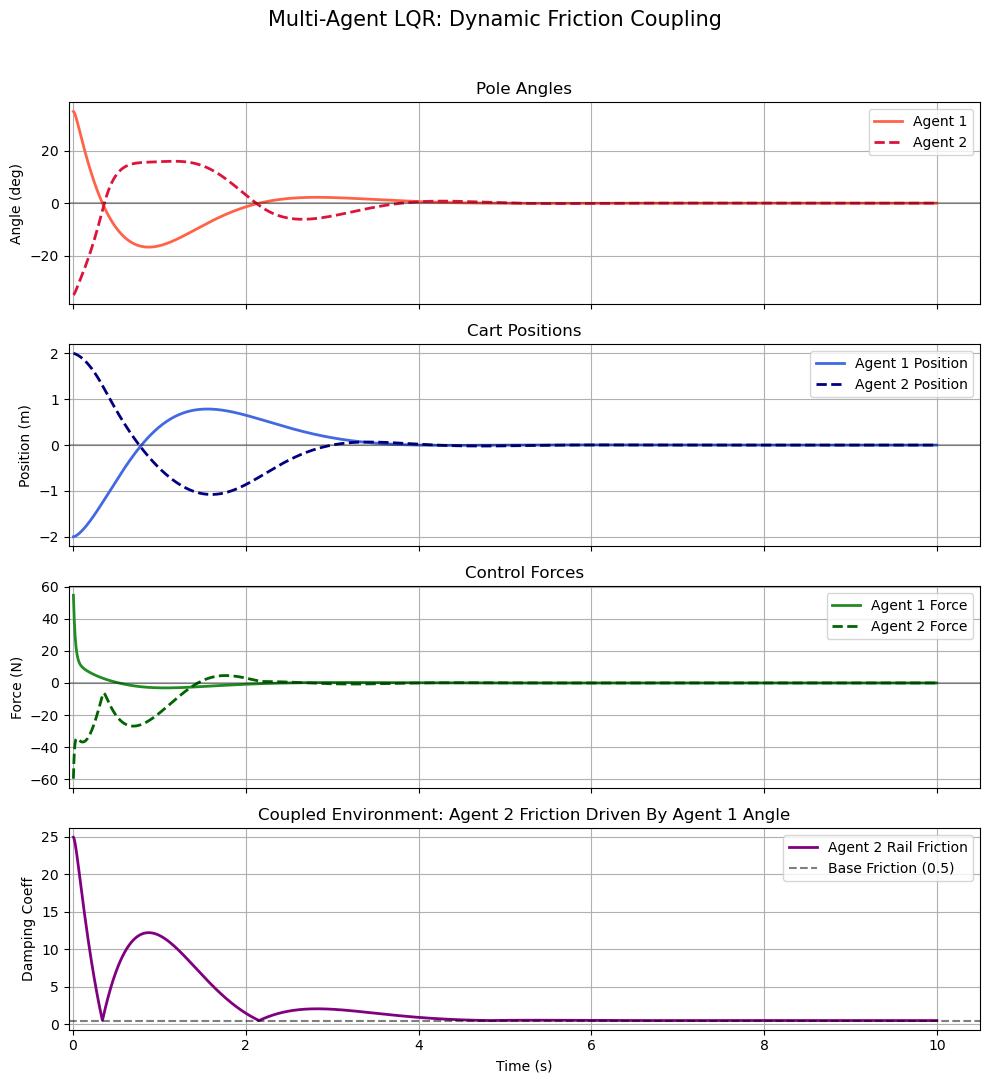

In [7]:
import time
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
import mujoco
import mujoco.viewer

# ============================================================
#                     MuJoCo MODEL
# ============================================================

CARTPOLE_XML = """
<mujoco model="multi_cartpole_coupled">

  <option gravity="0 0 -9.81" timestep="0.005"/>

  <default>
    <joint damping="0.0"/>
  </default>

  <worldbody>
    <!-- Rail 1 -->
    <geom name="rail1" type="capsule" pos="0 -0.2 0" size="0.02 30" euler="0 90 0" rgba="0.4 0.4 0.4 1" contype="0" conaffinity="0"/>
    
    <!-- Rail 2 -->
    <geom name="rail2" type="capsule" pos="0 0.2 0" size="0.02 30" euler="0 90 0" rgba="0.4 0.4 0.4 1" contype="0" conaffinity="0"/>

    <!-- Agent 1 (Controls Agent 2's Friction) -->
    <body name="cart1" pos="0 -0.2 0">
      <joint name="slider1" type="slide" axis="1 0 0" limited="true" range="-10 10" damping="0.5"/>
      <geom type="box" size="0.15 0.08 0.05" rgba="0.3 0.6 0.9 1" mass="1.0"/>
      <body name="pole1" pos="0 0 0.05">
        <joint name="hinge1" type="hinge" axis="0 1 0" damping="0.05"/>
        <geom type="capsule" fromto="0 0 0 0 0 0.5" size="0.015" rgba="0.85 0.35 0.15 1" mass="0.1"/>
        <geom type="sphere" pos="0 0 0.5" size="0.05" rgba="1 0.85 0.1 1" mass="0"/>
      </body>
    </body>

    <!-- Agent 2 (Friction dynamically shifts) -->
    <body name="cart2" pos="0 0.2 0">
      <!-- Damping here will be overwritten dynamically in the simulation loop -->
      <joint name="slider2" type="slide" axis="1 0 0" limited="true" range="-10 10" damping="0.5"/>
      <geom type="box" size="0.15 0.08 0.05" rgba="0.9 0.3 0.4 1" mass="1.0"/>
      <body name="pole2" pos="0 0 0.05">
        <joint name="hinge2" type="hinge" axis="0 1 0" damping="0.05"/>
        <geom type="capsule" fromto="0 0 0 0 0 0.5" size="0.015" rgba="0.35 0.85 0.4 1" mass="0.1"/>
        <geom type="sphere" pos="0 0 0.5" size="0.05" rgba="1 0.4 0.1 1" mass="0"/>
      </body>
    </body>

  </worldbody>

  <actuator>
    <motor name="cart_force1" joint="slider1" gear="1" ctrllimited="true" ctrlrange="-150 150"/>
    <motor name="cart_force2" joint="slider2" gear="1" ctrllimited="true" ctrlrange="-150 150"/>
  </actuator>

</mujoco>
"""

# ============================================================
#                 LQR TUNING PARAMETERS
# ============================================================

CONTROL_LIMIT = 1500.0

# Agent 1 Tuning (Standard)
Q1 = np.diag([1.0, 80.0, 0.5, 5.0])

# Agent 2 Tuning (Aggressive)
Q2 = np.diag([10.0, 200.0, 1.0, 10.0])

R = np.array([[0.01]])

# ============================================================
#             MATH & LINEARIZATION
# ============================================================

def get_physical_params(model):
    cart_body = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "cart1")
    pole_body = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "pole1")
    M = model.body_mass[cart_body]
    m = model.body_mass[pole_body]
    l = float(model.body_ipos[pole_body][2])
    g = abs(model.opt.gravity[2])
    return M, m, l, g

def build_linearised_system(M, m, l, g):
    total = M + m
    A = np.array([
        [0, 0, 1, 0],
        [0, 0, 0, 1],
        [0, -(m * g) / total, 0, 0],
        [0, g / l, 0, 0]
    ])
    B = np.array([
        [0],
        [0],
        [1 / total],
        [-1 / (l * total)]
    ])
    return A, B

def discretise(A, B, dt):
    n = A.shape[0]
    augmented = np.block([[A, B], [np.zeros((1, n + 1))]])
    expm = scipy.linalg.expm(augmented * dt)
    return expm[:n, :n], expm[:n, n:]

def compute_lqr_gain(Ad, Bd, Q, R):
    P = scipy.linalg.solve_discrete_are(Ad, Bd, Q, R)
    return np.linalg.inv(R + Bd.T @ P @ Bd) @ (Bd.T @ P @ Ad)

def get_states(model, data):
    def get_idx(joint_name):
        jnt_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, joint_name)
        return model.jnt_qposadr[jnt_id], model.jnt_dofadr[jnt_id]

    s1_p, s1_v = get_idx("slider1")
    h1_p, h1_v = get_idx("hinge1")
    s2_p, s2_v = get_idx("slider2")
    h2_p, h2_v = get_idx("hinge2")

    state1 = np.array([data.qpos[s1_p], data.qpos[h1_p], data.qvel[s1_v], data.qvel[h1_v]])
    state2 = np.array([data.qpos[s2_p], data.qpos[h2_p], data.qvel[s2_v], data.qvel[h2_v]])
    return state1, state2

# ============================================================
#                 MAIN SIMULATION
# ============================================================

def run_simulation(render=True, duration=15.0):
    model = mujoco.MjModel.from_xml_string(CARTPOLE_XML)
    data = mujoco.MjData(model)

    dt = model.opt.timestep
    M, m, l, g = get_physical_params(model)
    A, B = build_linearised_system(M, m, l, g)
    Ad, Bd = discretise(A, B, dt)
    
    K1 = compute_lqr_gain(Ad, Bd, Q1, R)
    K2 = compute_lqr_gain(Ad, Bd, Q2, R)

    mujoco.mj_resetData(model, data)

    s1_p = model.jnt_qposadr[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, "slider1")]
    h1_p = model.jnt_qposadr[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, "hinge1")]
    s2_p = model.jnt_qposadr[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, "slider2")]
    h2_p = model.jnt_qposadr[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, "hinge2")]
    
    # We need Agent 2's velocity DOFs index to alter its damping
    s2_v = model.jnt_dofadr[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, "slider2")]

    # Set Initial Conditions (35 degrees)
    data.qpos[s1_p] = -2.0
    data.qpos[h1_p] = np.deg2rad(35.0)
    data.qpos[s2_p] = 2.0
    data.qpos[h2_p] = np.deg2rad(-35.0)

    mujoco.mj_forward(model, data)

    steps = int(duration / dt)
    times, states1, states2, controls1, controls2, damping_history = [], [], [], [], [], []

    ctrl1_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "cart_force1")
    ctrl2_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "cart_force2")

    if render:
        with mujoco.viewer.launch_passive(model, data) as viewer:
            start = time.time()
            for _ in range(steps):
                if not viewer.is_running():
                    break

                st1, st2 = get_states(model, data)
                
                # --- THE COUPLING MECHANISM ---
                # Agent 2's cart damping = Base(0.5) + Multiplier * |Agent 1 Pole Angle|
                # 35 degrees is ~0.61 radians, yielding a massive friction spike at the start.
                current_theta1 = data.qpos[h1_p]
                dynamic_damping = 0.5 + 40.0 * abs(current_theta1)
                model.dof_damping[s2_v] = dynamic_damping
                # ------------------------------

                c1 = np.clip(float((-K1 @ st1)[0]), -CONTROL_LIMIT, CONTROL_LIMIT)
                c2 = np.clip(float((-K2 @ st2)[0]), -CONTROL_LIMIT, CONTROL_LIMIT)

                data.ctrl[ctrl1_id] = c1
                data.ctrl[ctrl2_id] = c2

                mujoco.mj_step(model, data)

                times.append(data.time)
                states1.append(st1.copy())
                states2.append(st2.copy())
                controls1.append(c1)
                controls2.append(c2)
                damping_history.append(dynamic_damping)

                elapsed = time.time() - start
                if data.time > elapsed:
                    time.sleep(data.time - elapsed)

                viewer.sync()

    return np.array(times), np.array(states1), np.array(states2), np.array(controls1), np.array(controls2), np.array(damping_history)

# ============================================================
#             PEAK CALCULATION AND PRINTING
# ============================================================

def print_peaks(times, states1, states2, controls1, controls2, damping):
    pole_angle1 = np.rad2deg(states1[:, 1])
    pole_angle2 = np.rad2deg(states2[:, 1])
    cart_pos1 = states1[:, 0]
    cart_pos2 = states2[:, 0]

    def get_max_info(data, time_data):
        idx = np.argmax(np.abs(data))
        return data[idx], time_data[idx]

    print("\n========== Peak Values ==========")
    val, t = get_max_info(pole_angle1, times)
    print(f"Agent 1 Max Pole Angle : {val:8.3f} deg at {t:6.2f} s")
    val, t = get_max_info(pole_angle2, times)
    print(f"Agent 2 Max Pole Angle : {val:8.3f} deg at {t:6.2f} s")
    
    val, t = get_max_info(cart_pos1, times)
    print(f"Agent 1 Max Position   : {val:8.3f} m   at {t:6.2f} s")
    val, t = get_max_info(cart_pos2, times)
    print(f"Agent 2 Max Position   : {val:8.3f} m   at {t:6.2f} s")
    
    val, t = get_max_info(controls1, times)
    print(f"Agent 1 Max Force      : {val:8.3f} N   at {t:6.2f} s")
    val, t = get_max_info(controls2, times)
    print(f"Agent 2 Max Force      : {val:8.3f} N   at {t:6.2f} s")
    
    val, t = get_max_info(damping, times)
    print(f"Agent 2 Peak Damping   : {val:8.3f}     at {t:6.2f} s")
    print("=================================\n")

# ============================================================
#                 PLOTTING
# ============================================================

def plot_results(times, states1, states2, controls1, controls2, damping_history):
    pole_angle1 = np.rad2deg(states1[:, 1])
    cart_pos1 = states1[:, 0]
    
    pole_angle2 = np.rad2deg(states2[:, 1])
    cart_pos2 = states2[:, 0]

    fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
    fig.suptitle("Multi-Agent LQR: Dynamic Friction Coupling", fontsize=15)

    # 1. Pole Angles
    axes[0].plot(times, pole_angle1, color="tomato", linewidth=2, label="Agent 1")
    axes[0].plot(times, pole_angle2, color="crimson", linewidth=2, linestyle="--", label="Agent 2")
    axes[0].axhline(0, color="black", linestyle="-", alpha=0.3)
    axes[0].set_ylabel("Angle (deg)")
    axes[0].set_title("Pole Angles")
    axes[0].legend(loc="upper right")

    # 2. Cart Positions
    axes[1].plot(times, cart_pos1, color="royalblue", linewidth=2, label="Agent 1 Position")
    axes[1].plot(times, cart_pos2, color="navy", linewidth=2, linestyle="--", label="Agent 2 Position")
    axes[1].axhline(0, color="black", linestyle="-", alpha=0.3)
    axes[1].set_ylabel("Position (m)")
    axes[1].set_title("Cart Positions")
    axes[1].legend(loc="upper right")

    # 3. Control Forces
    axes[2].plot(times, controls1, color="forestgreen", linewidth=2, label="Agent 1 Force")
    axes[2].plot(times, controls2, color="darkgreen", linewidth=2, linestyle="--", label="Agent 2 Force")
    axes[2].axhline(0, color="black", linestyle="-", alpha=0.3)
    axes[2].set_ylabel("Force (N)")
    axes[2].set_title("Control Forces")
    axes[2].legend(loc="upper right")
    
    # 4. Agent 2 Dynamic Damping
    axes[3].plot(times, damping_history, color="purple", linewidth=2, label="Agent 2 Rail Friction")
    axes[3].axhline(0.5, color="black", linestyle="--", alpha=0.5, label="Base Friction (0.5)")
    axes[3].set_ylabel("Damping Coeff")
    axes[3].set_xlabel("Time (s)")
    axes[3].set_title("Coupled Environment: Agent 2 Friction Driven By Agent 1 Angle")
    axes[3].legend(loc="upper right")

    for ax in axes:
        ax.grid(True)
        ax.set_xlim(left=-0.05)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# ============================================================
#                      MAIN
# ============================================================

if __name__ == "__main__":
    times, states1, states2, controls1, controls2, damping = run_simulation(
        render=True,
        duration=10.0
    )
    
    print_peaks(times, states1, states2, controls1, controls2, damping)
    plot_results(times, states1, states2, controls1, controls2, damping)

# Multi-Agent Non-Linear Dependant System

This is an example of a multi-agent non linear dependent system (reverse pendulum), where the friction coefficent of agent 2 is dependent on the pole angle of agent 1. As the pole angle is larger, the friction coefficent is also larger. This is shown in the graph, where the fricition of agent 2 is highest at the start, where the pole angle of agent 1 is also at the highest. Also during the oscillations when the pole of agent 1 is attempting to balance, the extra friction is not added to system 2 when the cart pole angle = 0. 

In [4]:
import mujoco
import mujoco.viewer
import numpy as np
from scipy.linalg import solve_continuous_are
from scipy.spatial.transform import Rotation

# =====================================================
# Load Model
# =====================================================
model = mujoco.MjModel.from_xml_path(
    r"C:\Users\ebiel\OneDrive\Documents\task3\mujoco_menagerie\bitcraze_crazyflie_2\scene.xml"
)
data = mujoco.MjData(model)

# Physical Constants
g, m = 9.81, 0.027
Ix, Iy, Iz = 2.3951e-5, 2.3951e-5, 3.2347e-5
hover_thrust = 0.26487

# Actuator gears directly from the scene.xml
gear_roll = -0.00001
gear_pitch = -0.00001
gear_yaw = -0.00001

# =====================================================
# Linear Model Matrices
# =====================================================
A = np.zeros((12, 12))
A[0,3] = 1; A[1,4] = 1; A[2,5] = 1
A[3,7] = g; A[4,6] = -g 
A[6,9] = 1; A[7,10] = 1; A[8,11] = 1

B = np.zeros((12,4))
B[5,0] = 1/m                         # Thrust maps directly (gear=1 in xml)
B[9,1] = gear_roll / Ix              # Map MuJoCo ctrl signal to roll accel
B[10,2] = gear_pitch / Iy            # Map MuJoCo ctrl signal to pitch accel
B[11,3] = gear_yaw / Iz              # Map MuJoCo ctrl signal to yaw accel

# =====================================================
# Q and R Matrices
# =====================================================
Q = np.diag([
    50.0,  # x
    50.0,  # y
    100.0, # z
    10.0,  # vx
    10.0,  # vy
    20.0,  # vz
    100.0, # roll
    100.0, # pitch
    50.0,  # yaw
    10.0,  # roll_rate
    10.0,  # pitch_rate
    10.0   # yaw_rate
])

# R Matrix: Because B now includes the tiny gear multiplier, the LQR knows 
# it needs to output values near the XML's [-1, 1] ctrlrange. 
R = np.diag([1.0, 1.0, 1.0, 1.0])

P = solve_continuous_are(A, B, Q, R)
K = np.linalg.inv(R) @ B.T @ P

def get_state():
    q = data.qpos[3:7]
    quat = np.array([q[1], q[2], q[3], q[0]])
    yaw, pitch, roll = Rotation.from_quat(quat).as_euler("ZYX")
    return np.array([
        data.qpos[0], data.qpos[1], data.qpos[2],
        data.qvel[0], data.qvel[1], data.qvel[2],
        roll, pitch, yaw,
        data.qvel[3], data.qvel[4], data.qvel[5]
    ])

# Initialization
x_ref = np.array([0, 0, 1.0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
data.qpos[2] = 0.1
data.qpos[3] = 1.0
mujoco.mj_forward(model, data)

takeoff_time = 2.0

with mujoco.viewer.launch_passive(model, data) as viewer:
    while viewer.is_running():
        x = get_state()
        u = -K @ (x - x_ref)
        
        # Calculate thrust
        t = data.time
        scale = min(t / takeoff_time, 1.0)
        thrust = (scale * hover_thrust) + u[0]
        
        # Apply Mapping
        # Note: We now clamp the moments to [-1, 1] because that is 
        # the 'ctrlrange' explicitly defined in your scene.xml
        data.ctrl[0] = np.clip(thrust, 0.0, 0.35)
        data.ctrl[1] = np.clip(u[1], -1.0, 1.0)
        data.ctrl[2] = np.clip(u[2], -1.0, 1.0)
        data.ctrl[3] = np.clip(u[3], -1.0, 1.0)

        # Wind Gust (pushes slightly +X)
        if 5.0 < data.time < 5.1:
            data.xfrc_applied[1] = np.array([0.15, 0.00, 0.00, 0, 0, 0])
        else:
            data.xfrc_applied[1] = np.zeros(6)
            
        mujoco.mj_step(model, data)
        viewer.sync()

# Single Agent Non-Linear System (Arial Quadrotor)

This is also an example of a single agent non-linear system, where an arial quadrotor (a drone) is hovering in the air, using LQR to control it to bring it into its "hover position" which is defined. Then, a small gust of wind pushes the drone to the right, which allows the LQR to be seen adjusting the positon of the drone in real time. 


Optimal Discrete LQR Gain Matrix K computed.

Running Moving Platoon Controller Loop...


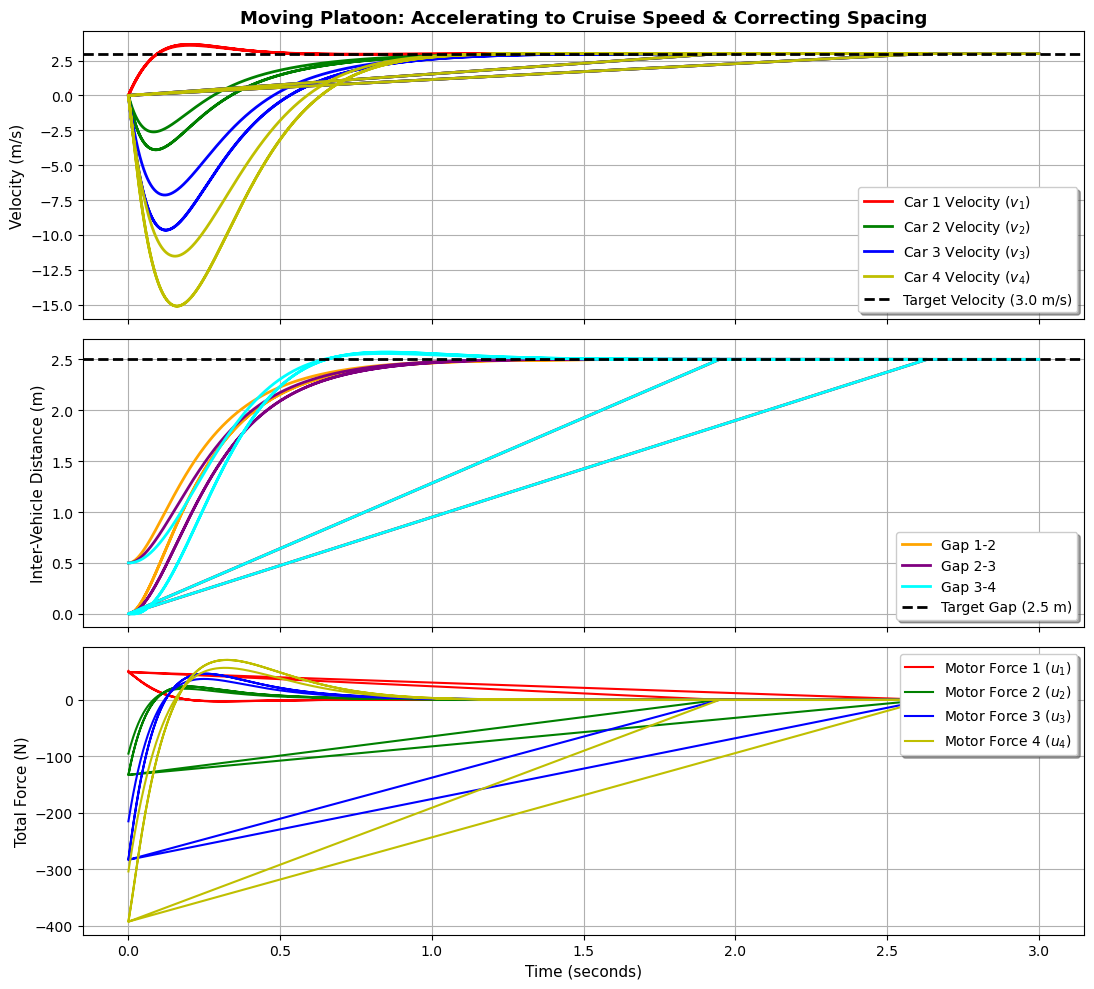

In [8]:
import mujoco
import mujoco.viewer
import numpy as np
import scipy.linalg as la
import scipy.signal as signal
import matplotlib.pyplot as plt
import time

# =============================================================================
# 1. SYSTEM DEFINITIONS & TARGET TRAJECTORIES
# =============================================================================
# Platoon Goals
V_TARGET = 3.0   # Platoon cruising velocity (m/s)
D_TARGET = 2.5   # Target spacing gap between each car (meters)

# Individual vehicle masses
M = [1.0, 1.2, 1.4, 1.6]

# Look-ahead control coupling gains (representing virtual springs/dampers)
K_SPACING = 20.0  # k
C_VELOCITY = 3.5  # c

NUM_VEHICLES = len(M)
NUM_STATES = 2 * NUM_VEHICLES
NUM_INPUTS = NUM_VEHICLES

DT = 0.002

# =============================================================================
# 2. CONTINUOUS-TIME STATE SPACE MATRIX (ERROR DYNAMICS)
# =============================================================================
# The A_c and B_c matrices govern the ERROR dynamics: dx_error/dt = A_c * x_error + B_c * u
A_c = np.zeros((NUM_STATES, NUM_STATES))
B_c = np.zeros((NUM_STATES, NUM_INPUTS))

for i in range(NUM_VEHICLES):
    row_p = 2 * i
    row_v = 2 * i + 1
    
    A_c[row_p, row_v] = 1.0
    B_c[row_v, i] = 1.0 / M[i]
    
    # Self-dynamics
    A_c[row_v, row_p] = -K_SPACING / M[i]
    A_c[row_v, row_v] = -C_VELOCITY / M[i]
    
    # Coupling with vehicle ahead
    if i > 0:
        lead_p = 2 * (i - 1)
        lead_v = 2 * (i - 1) + 1
        A_c[row_v, lead_p] = K_SPACING / M[i]
        A_c[row_v, lead_v] = C_VELOCITY / M[i]

# =============================================================================
# 3. DISCRETIZATION (ZOH)
# =============================================================================
C_dummy = np.eye(NUM_STATES)
D_dummy = np.zeros((NUM_STATES, NUM_INPUTS))
A_d, B_d, _, _, _ = signal.cont2discrete((A_c, B_c, C_dummy, D_dummy), DT, method='zoh')

# =============================================================================
# 4. DISCRETE LQR DESIGN (DARE)
# =============================================================================
# Penalize positional tracking errors heavily to enforce strict spacing
Q = np.diag([200.0, 10.0, 200.0, 10.0, 200.0, 10.0, 200.0, 10.0])
R = np.eye(NUM_INPUTS) * 0.05

P = la.solve_discrete_are(A_d, B_d, Q, R)
K = la.inv(R + B_d.T @ P @ B_d) @ (B_d.T @ P @ A_d)

print("\nOptimal Discrete LQR Gain Matrix K computed.")

# =============================================================================
# 5. MUJOCO ENVIRONMENT SETUP
# =============================================================================
model = mujoco.MjModel.from_xml_path('platoon.xml')
data = mujoco.MjData(model)

# Initial State: Starts at rest, heavily bunched up (0.5m spacing instead of target 2.5m)
# The controller must expand the distances while simultaneously accelerating to V_TARGET
data.qpos[:] = [0.0, -0.5, -1.0, -1.5]
data.qvel[:] = [0.0, 0.0, 0.0, 0.0]
mujoco.mj_forward(model, data)

T_MAX = 3.0  

log_t = []
log_actual_pos = []
log_actual_vel = []
log_u = []

# =============================================================================
# 6. SIMULATION RUN AND VISUALIZATION LOOP
# =============================================================================
print("\nRunning Moving Platoon Controller Loop...")

with mujoco.viewer.launch_passive(model, data) as viewer:
    time.sleep(0.5)
    
    # Configure camera to view the side profile of the cars from a distance
    viewer.cam.elevation = -15
    viewer.cam.distance = 12.0
    
    while data.time < T_MAX and viewer.is_running():
        step_start = time.time()
        
        # 1. Calculate the nominal target states for the current time
        # p_star_i(t) = v_target * t - (i-1) * D_target
        p_star = V_TARGET * data.time + np.array([0, -D_TARGET, -2*D_TARGET, -3*D_TARGET])
        
        # 2. Calculate State Errors (This is what the LQR actually sees)
        q_err = data.qpos - p_star
        v_err = data.qvel - V_TARGET
        
        x_err = np.zeros(NUM_STATES)
        x_err[0::2] = q_err
        x_err[1::2] = v_err
        
        # 3. Compute optimal discrete LQR control input for the error state
        u_lqr = -K @ x_err
        
        # 4. Calculate total actuator output
        u_total = np.zeros(NUM_INPUTS)
        for i in range(NUM_VEHICLES):
            if i == 0:
                base_force = -K_SPACING * x_err[0] - C_VELOCITY * x_err[1]
            else:
                base_force = (K_SPACING * (x_err[2*(i-1)] - x_err[2*i]) + 
                              C_VELOCITY * (x_err[2*(i-1)+1] - x_err[2*i+1]))
            u_total[i] = base_force + u_lqr[i]
            
        data.ctrl[:] = u_total
        
        # Log absolute physics data for plotting
        log_t.append(data.time)
        log_actual_pos.append(data.qpos.copy())
        log_actual_vel.append(data.qvel.copy())
        log_u.append(u_total.copy())
        
        # Track the leading car with the viewer camera so they don't drive out of frame
        viewer.cam.lookat[0] = data.qpos[0] - 2.0  # Center camera slightly behind leader
        
        mujoco.mj_step(model, data)
        viewer.sync()
        
        elapsed = time.time() - step_start
        if DT > elapsed:
            time.sleep(DT - elapsed)

# =============================================================================
# 7. METRIC PLOTTING GENERATION
# =============================================================================
t_arr = np.array(log_t)
p_arr = np.array(log_actual_pos)
v_arr = np.array(log_actual_vel)
u_arr = np.array(log_u)

fig, axs = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
colors = ['r', 'g', 'b', 'y']

# Subplot A: Absolute Velocities
for i in range(NUM_VEHICLES):
    axs[0].plot(t_arr, v_arr[:, i], label=f'Car {i+1} Velocity ($v_{i+1}$)', color=colors[i], linewidth=2)
axs[0].axhline(V_TARGET, color='black', linestyle='--', linewidth=2, label=f'Target Velocity ({V_TARGET} m/s)')
axs[0].set_ylabel('Velocity (m/s)', fontsize=11)
axs[0].set_title('Moving Platoon: Accelerating to Cruise Speed & Correcting Spacing', fontsize=13, fontweight='bold')
axs[0].legend(loc='lower right', shadow=True)
axs[0].grid(True)

# Subplot B: Inter-Vehicle Spacing
axs[1].plot(t_arr, p_arr[:, 0] - p_arr[:, 1], label='Gap 1-2', color='orange', linewidth=2)
axs[1].plot(t_arr, p_arr[:, 1] - p_arr[:, 2], label='Gap 2-3', color='purple', linewidth=2)
axs[1].plot(t_arr, p_arr[:, 2] - p_arr[:, 3], label='Gap 3-4', color='cyan', linewidth=2)
axs[1].axhline(D_TARGET, color='black', linestyle='--', linewidth=2, label=f'Target Gap ({D_TARGET} m)')
axs[1].set_ylabel('Inter-Vehicle Distance (m)', fontsize=11)
axs[1].legend(loc='lower right', shadow=True)
axs[1].grid(True)

# Subplot C: Total Control Actuation Forces
for i in range(NUM_VEHICLES):
    axs[2].plot(t_arr, u_arr[:, i], label=f'Motor Force {i+1} ($u_{i+1}$)', color=colors[i], linewidth=1.5)
axs[2].set_ylabel('Total Force (N)', fontsize=11)
axs[2].set_xlabel('Time (seconds)', fontsize=11)
axs[2].legend(loc='upper right', shadow=True)
axs[2].grid(True)

plt.tight_layout()
plt.show()

# Multi-Agent Linear Dependent System

This is a multi agent linear system where the vehicles start bunched up, and their end goal is to have a constant distance between them, while also moving at a constant velocity. Each car's position and velocity depends on the car in front and behind it, making it a dependent system. It is a linear system because there are no non-linear physics terms, such as angles and aerodynamic drag. 